In [5]:
import numpy as np
import pandas as pd
from scipy.linalg import eig
from matplotlib import pyplot as plt
import seaborn as sns

In [6]:
# Load dataset
data = pd.read_csv('customer_metrics_output_new.csv')     

In [7]:
# Define segment to index mapping
segments = ['Rock','Bronze','Silver', 'Gold', 'Diamond', 'Platinum']
cluster_to_segment = {0: 'Rock', 1: 'Bronze',2:'Silver', 3: 'Gold', 4: 'Diamond',5: 'Platinum'} 
segment_to_index = {segment: i for i, segment in enumerate(segments)}
n_segments = len(segments)

In [8]:
# Creating Transition Counts 
transition_counts = np.zeros((n_segments, n_segments), dtype=int)

for customer_id, group in data.groupby('CustomerName'):
    group = group.sort_values(['year', 'half_year'])
    clusters_sequence = group['Cluster'].map(cluster_to_segment).values  # Convert clusters to segments
    for i in range(len(clusters_sequence) - 1):
        current_segment = clusters_sequence[i]
        next_segment = clusters_sequence[i + 1]
        if current_segment in segment_to_index and next_segment in segment_to_index:
            current_index = segment_to_index[current_segment]
            next_index = segment_to_index[next_segment]
            transition_counts[current_index, next_index] += 1

In [9]:
# Creating Transition matrix with calculated transition counts 
epsilon = 1e-10
transition_matrix = transition_counts / transition_counts.sum(axis=1, keepdims=True)
transition_matrix = np.nan_to_num(transition_matrix, nan=0) # Handle rows with no transitions
print(transition_counts)


[[2812   36    2    0    0    0]
 [  42  129    7    0    0    0]
 [   3   11   35    1    0    0]
 [   0    0    3   12    1    1]
 [   0    0    0    2    9    2]
 [   0    0    1    1    3    4]]


In [10]:
# Create a transitional matrix dataframe
transition_matrix_df = pd.DataFrame(
    transition_matrix,
    index=segments,
    columns=segments
)
print(transition_matrix_df)

              Rock    Bronze    Silver      Gold   Diamond  Platinum
Rock      0.986667  0.012632  0.000702  0.000000  0.000000  0.000000
Bronze    0.235955  0.724719  0.039326  0.000000  0.000000  0.000000
Silver    0.060000  0.220000  0.700000  0.020000  0.000000  0.000000
Gold      0.000000  0.000000  0.176471  0.705882  0.058824  0.058824
Diamond   0.000000  0.000000  0.000000  0.153846  0.692308  0.153846
Platinum  0.000000  0.000000  0.111111  0.111111  0.333333  0.444444


In [11]:
# Assign minimum thresholds
thresholds = {
    0: 0.01,  # Rock (No threshold)
    1: 0.01,  # Bronze
    2: 0.05,  # Silver
    3: 0.05,  # Gold
    4: 0.05,  # Diamond
    5: 0.05    # Platinum
}

In [12]:
# Assign  thersholds as required
UPPER_THRESHOLD = 60 
LOWER_THRESHOLD = 40

In [13]:

def normalize_weights(values):
    "Normalize values to range [0, 1] using Min-Max Scaling."
    min_val, max_val = np.min(values), np.max(values)
    return (values - min_val) / (max_val - min_val) if max_val > min_val else np.ones_like(values)

def predict_next_cluster(current_cluster, transition_matrix, TotalRevenue, TotalProfit, all_revenues, all_profits):
    "Predict the next cluster with customer-specific weighted probabilities."
    
    # Normalize revenue and profit for individual scaling
    norm_revenue = normalize_weights(np.array(all_revenues))
    norm_profit = normalize_weights(np.array(all_profits))

    # Compute individual weight (relative to dataset)
    customer_weight = (0.7 * norm_revenue[np.where(all_revenues == TotalRevenue)][0]) + \
                      (0.3 * norm_profit[np.where(all_profits == TotalProfit)][0])

    # Extract transition probabilities for current cluster
    transitional_prob = transition_matrix[current_cluster]
    scaling_factor = 6 # Adjust this value to control spread
    weighted_probabilities = np.exp(transitional_prob * customer_weight * scaling_factor)

    # Adjust probabilities using weighted softmax to enhance differentiation
    probabilities = weighted_probabilities / np.sum(weighted_probabilities)

    # Handle cases where probability sum is zero
    if np.sum(probabilities) == 0:
        return current_cluster, 0  

    # Select the most likely next cluster
    next_cluster_idx = np.argmax(probabilities)
    probability = probabilities[next_cluster_idx]

    return next_cluster_idx, probability

def apply_prediction(row, all_revenues, all_profits):
    next_cluster, prob = predict_next_cluster(row['Cluster'], transition_matrix, 
                                              row['TotalRevenue'], row['TotalProfit'], 
                                              all_revenues, all_profits)
    scaling_factor_prob = 2
    prob = prob * 100 * scaling_factor_prob
    #print(f"prob for customer {row['CustomerName']}: {prob}")

    if row['Cluster'] == 5 and prob >= UPPER_THRESHOLD:
        adjusted_cluster = 5
    elif prob >= UPPER_THRESHOLD and row['Cluster'] != 5:
        adjusted_cluster = (row['Cluster'] + 1)
    elif LOWER_THRESHOLD <= prob < UPPER_THRESHOLD or row['Cluster'] == 0 and prob <= LOWER_THRESHOLD:
        adjusted_cluster = row['Cluster']
    else:
        adjusted_cluster = row['Cluster'] - 1
    
    return pd.Series([adjusted_cluster, prob])

# Collect all revenues and profits for normalization
all_revenues = data['TotalRevenue'].values
all_profits = data['TotalProfit'].values

# Apply the new prediction method
data[['nextCluster', 'AssignedProb']] = data.apply(lambda row: apply_prediction(row, all_revenues, all_profits), axis=1)
data['AssignedProb'] = (data['AssignedProb']).round(3).clip(10,100)




In [14]:
# Calculate revenue and profit growth per customer
data['RevenueGrowth'] = data.groupby('CustomerName')['TotalRevenue'].pct_change().fillna(0).round(3)*100
data['ProfitGrowth'] = data.groupby('CustomerName')['TotalProfit'].pct_change().fillna(0).round(3)*100

def probability_of_moving_up(customer_row, transition_matrix):
    current_cluster = int(customer_row['Cluster'])

    if current_cluster >= len(transition_matrix):
        return 0.0

    # Base probability of promotion
    base_prob = sum(transition_matrix[current_cluster][current_cluster + 1:])

    if base_prob == 0:
        return 0.0

    # Get growth metrics, handle bad data
    rev_growth = customer_row.get('RevenueGrowth', 0)
    prof_growth = customer_row.get('ProfitGrowth', 0)

    if not np.isfinite(rev_growth): rev_growth = 0
    if not np.isfinite(prof_growth): prof_growth = 0
    if np.isnan(rev_growth): rev_growth = 0
    if np.isnan(prof_growth): prof_growth = 0

    # Scaled growth score
    growth_score = 0.8 * rev_growth + 0.2 * prof_growth

    # Sigmoid scale to smooth and bound the influence of growth
    # Example: -100 => ~0, 0 => 0.5, 30 => ~0.95
    sigmoid = lambda x: 1 / (1 + np.exp(-x / 15))
    boost_factor = sigmoid(growth_score)

    # Final move-up probability (allow boost up to 3x base, capped at 1)
    adjusted_prob = min(1.0, base_prob * (1 + 2 * boost_factor))  # up to 3x

    return round(adjusted_prob * 100,2)

data['MoveUpProbability'] = data.apply(lambda row: probability_of_moving_up(row, transition_matrix), axis=1)

In [15]:
def apply_threshold(cluster, next_cluster, probability):
    threshold = thresholds[cluster]
    if next_cluster > cluster:   # Moving Up
        return "Moving Up"
    elif next_cluster < cluster: # Moving Down + Probability above threshold
        return "At Risk"
    elif next_cluster == cluster:
        return "Safe"
    
data['RiskLevel'] = data.apply(lambda row: apply_threshold(row['Cluster'], row['nextCluster'], row['AssignedProb']), axis=1)

In [16]:

data['Current_Tier'] = data['Cluster'].map(cluster_to_segment)
data['Next_Tier'] = data['nextCluster'].astype(int).map(cluster_to_segment)
data['Risk_Cluster_Tier_Pair'] = (
    data['Cluster'].astype(str) + '-' + 
    data['nextCluster'].astype(str) + '-' + 
    data['RiskLevel'] + '-' + 
    data['Current_Tier'] + '-' + 
    data['Next_Tier']
)


In [17]:
def determine_risk(prob):
    if prob > UPPER_THRESHOLD:
        return "Moving Up"
    elif prob >= LOWER_THRESHOLD and prob<UPPER_THRESHOLD:
        return "Safe"
    else:
        return "At Risk"

def custom_risk_aggregation(group, prob):
    group = group.dropna()  # Drop NaN values to prevent errors
    if group.empty:
        return "0-0-Safe-Rock-Rock"  # or some fallback default
    mode_values = group.mode()
    if mode_values.empty:
        return "0-0-Safe-Rock-Rock"

    mode_str = mode_values.iloc[0]

    if isinstance(mode_values, pd.Series) and mode_values.str.contains("Moving Up").any():
        risk_category = determine_risk(prob)
        moving_up_rows = group[group.str.contains("Moving Up", na=False)]
        if not moving_up_rows.empty:
            return moving_up_rows.iloc[0]
        base_values = mode_str.split('-')
        return f"{base_values[0]}-{base_values[1]}-{risk_category}-{base_values[3]}-{base_values[4]}"
    else:
        return mode_str



In [18]:

# Aggregate results per customer
aggregated = data.groupby([ 'CustomerName'], sort=False).agg({
    'TotalRevenue': 'mean',
    'TotalProfit': 'mean',
    'AssignedProb': 'mean',
    'MoveUpProbability' :'mean'
}).reset_index()

#aggregated[['Current_Tier', 'Next_Tier']] = aggregated['Tier_Pair'].str.split('-', expand=True)
aggregated['Risk_Cluster_Tier_Pair'] = data.groupby(['CustomerName'])\
    .apply(lambda group: custom_risk_aggregation(group['Risk_Cluster_Tier_Pair'], group['AssignedProb'].mean()))\
    .reset_index(drop=True)
aggregated[['Cluster', 'nextCluster','RiskLevel','Current_Tier','Next_Tier']] = aggregated['Risk_Cluster_Tier_Pair'].str.split('-', expand=True)
aggregated['Cluster'] = aggregated['Cluster'].astype(int)
aggregated['nextCluster'] = aggregated['nextCluster'].astype(float)
aggregated.drop(columns=['Risk_Cluster_Tier_Pair'], inplace=True) # Drop the temporary column

aggregated['AssignedProb'] = aggregated['AssignedProb'].round(3)
aggregated['MoveUpProbability'] = aggregated['MoveUpProbability'].round(3)
aggregated['TotalRevenue'] = aggregated['TotalRevenue'].round(2)
aggregated['TotalProfit'] = aggregated['TotalProfit'].round(2)

# Print the aggregated results for review
print("\n Aggregated Customer Risk Overview:\n")
print(aggregated.head(15))



 Aggregated Customer Risk Overview:

                         CustomerName  TotalRevenue  TotalProfit  \
0                  ADAMS PLC AND SONS      14994.20      6456.84   
1                       ADAMS PLC LTD        174.88        37.81   
2     AHMED, MURPHY AND STEVENSON LLC        161.65        68.20   
3                  AHMED-BAILEY GROUP       3842.51      1075.90   
4                   AKHTAR-AKHTAR LTD        700.76       238.32   
5                  AKHTAR-WHEELER LTD      73412.95     24240.38   
6                   ALEXANDER PLC LTD       6250.00      6250.00   
7      ALEXANDER, RUIZ AND FOSTER LLC        686.50        63.01   
8               ALI, FOX AND GRAY INC       1352.17        88.01   
9         ALLEN, CARSON AND PEREZ LTD       2353.24      1042.08   
10  ALLEN, JOHNSON AND SAUNDERS GROUP          0.00         0.00   
11                  ALLEN-HARDING INC        334.42       120.80   
12                 ALLEN-LAWSON GROUP        550.64       262.14   
13        

C:\Users\andyh\AppData\Local\Temp\ipykernel_35328\4266537316.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: custom_risk_aggregation(group['Risk_Cluster_Tier_Pair'], group['AssignedProb'].mean()))\


In [19]:

# Save datasets
data.to_csv("../data/raw/new_dataset.csv", index=False)
aggregated.to_csv("../data/raw/aggregated_dataset.csv", index=False)
aggregated_dataset = pd.read_csv('../data/raw/aggregated_dataset.csv')

# Filter customers with RiskLevel as 'Moving up' or 'At Risk'
moving_up_customers = aggregated_dataset[aggregated_dataset['RiskLevel'] == 'Moving Up']
at_risk_customers = aggregated_dataset[aggregated_dataset['RiskLevel'] == 'At Risk']
prob_customers = aggregated_dataset[aggregated_dataset['AssignedProb'] > UPPER_THRESHOLD]
platinum_prob_customers = aggregated_dataset[(aggregated_dataset['AssignedProb'] > UPPER_THRESHOLD) & (aggregated_dataset['RiskLevel'] == 'Safe')]

# Print the relevant columns
print("\nCustomers MOVING UP:")
print(moving_up_customers[[ 'CustomerName','Current_Tier', 'Next_Tier', 'MoveUpProbability']])
print(f"\nCustomers Assigned Probability above {UPPER_THRESHOLD} and Safe:")
print(platinum_prob_customers[['CustomerName','AssignedProb']])
print("\nCustomers AT RISK:")
print(at_risk_customers[['CustomerName', 'Current_Tier', 'Next_Tier', 'AssignedProb']].head(10))



Customers MOVING UP:
                        CustomerName Current_Tier Next_Tier  MoveUpProbability
55              BARRERA-MITCHELL LTD         Gold   Diamond             24.705
102                  BRADLEY LTD LTD       Silver      Gold              2.308
111       BROWN, BURKE AND SMITH LLC       Silver      Gold              4.165
234  DOMINGUEZ, STONE AND WEAVER LLC         Gold   Diamond             10.185
261        EVANS, SMITH AND ROSS INC       Silver      Gold             10.462
441                  JOHNSON LLC PLC         Gold   Diamond             13.353
470             JONES-EVANS AND SONS      Diamond  Platinum             32.118
515                   LEE-BOND GROUP      Diamond  Platinum             29.255
550                  MARSH LTD GROUP         Gold   Diamond             12.230
569           MAYO AND SONS AND SONS         Gold   Diamond             24.510
661  OWEN, WATKINS AND TOMLINSON INC      Diamond  Platinum             19.965
713       POWELL, LEE AND ASHT

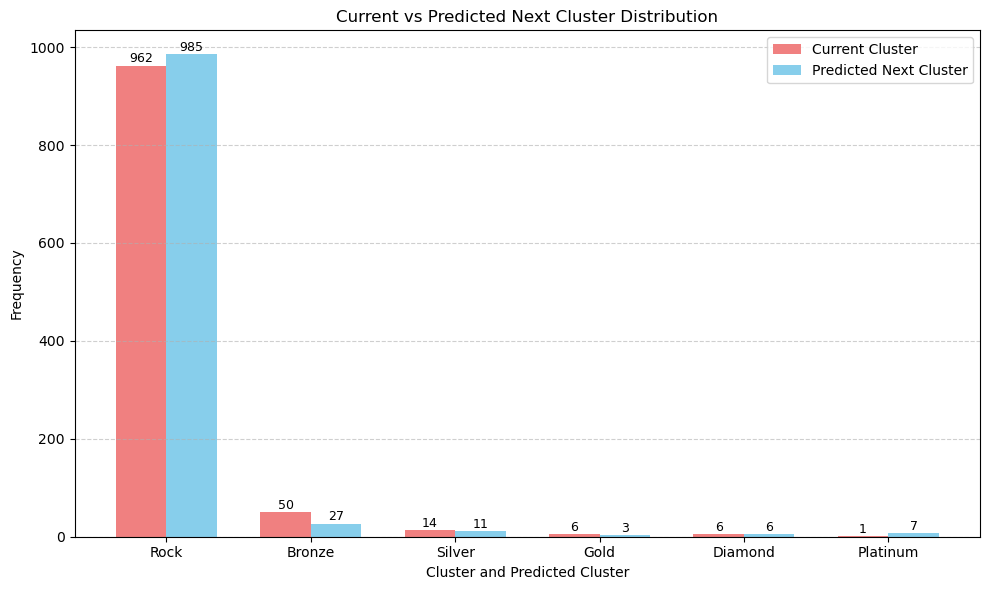

In [20]:

predicted_counts = aggregated_dataset['nextCluster'].value_counts().sort_index()
current_counts = aggregated_dataset['Cluster'].value_counts().sort_index()

# Ensure all clusters (0–5) are represented, even if missing
all_clusters = range(6)
current_counts = current_counts.reindex(all_clusters, fill_value=0)
predicted_counts = predicted_counts.reindex(all_clusters, fill_value=0)

# Bar positions
x = np.arange(len(all_clusters))  # [0, 1, 2, 3, 4, 5]
width = 0.35  # width of each bar

# Plot
plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, current_counts.values, width, label='Current Cluster', color='lightcoral')
bars2 = plt.bar(x + width/2, predicted_counts.values, width, label='Predicted Next Cluster', color='skyblue')

# Add value labels on top
for bar in bars1 + bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=9)

# Custom cluster labels
plt.xticks(ticks=x, labels=segments)

plt.xlabel('Cluster and Predicted Cluster')
plt.ylabel('Frequency')
plt.title('Current vs Predicted Next Cluster Distribution')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


